In [1]:
from pathlib import Path

PROJECT_ROOT = Path("/scr/user/danielw9199/TrustPCB")

DATASET_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "DsPCBSD_plus"
    / "Data_YOLO"
)

TRAIN_IMAGES = DATASET_ROOT / "images" / "train"
VAL_IMAGES = DATASET_ROOT / "images" / "val"

TRAIN_LABELS = DATASET_ROOT / "labels" / "train"
VAL_LABELS = DATASET_ROOT / "labels" / "val"

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATASET_ROOT)

for path in [
    TRAIN_IMAGES,
    VAL_IMAGES,
    TRAIN_LABELS,
    VAL_LABELS,
]:
    print(path, "->", path.exists())

Project root: /scr/user/danielw9199/TrustPCB
Dataset root: /scr/user/danielw9199/TrustPCB/data/raw/DsPCBSD_plus/Data_YOLO
/scr/user/danielw9199/TrustPCB/data/raw/DsPCBSD_plus/Data_YOLO/images/train -> True
/scr/user/danielw9199/TrustPCB/data/raw/DsPCBSD_plus/Data_YOLO/images/val -> True
/scr/user/danielw9199/TrustPCB/data/raw/DsPCBSD_plus/Data_YOLO/labels/train -> True
/scr/user/danielw9199/TrustPCB/data/raw/DsPCBSD_plus/Data_YOLO/labels/val -> True


In [2]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def get_images(folder):
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

def get_labels(folder):
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    )

train_images = get_images(TRAIN_IMAGES)
val_images = get_images(VAL_IMAGES)

train_labels = get_labels(TRAIN_LABELS)
val_labels = get_labels(VAL_LABELS)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Total images:", len(train_images) + len(val_images))

print()

print("Train label files:", len(train_labels))
print("Validation label files:", len(val_labels))
print("Total label files:", len(train_labels) + len(val_labels))

Train images: 8208
Validation images: 2051
Total images: 10259

Train label files: 8208
Validation label files: 2051
Total label files: 10259


In [3]:
print("Example train images:")
for p in train_images[:5]:
    print(" ", p.name)

print("\nExample train labels:")
for p in train_labels[:5]:
    print(" ", p.name)

print("\nExample validation images:")
for p in val_images[:5]:
    print(" ", p.name)

print("\nExample validation labels:")
for p in val_labels[:5]:
    print(" ", p.name)

Example train images:
  0003730.jpg
  0003759.jpg
  0004469.jpg
  0004990.jpg
  0006194.jpg

Example train labels:
  0003730.txt
  0003759.txt
  0004469.txt
  0004990.txt
  0006194.txt

Example validation images:
  0014089.jpg
  0032075.jpg
  0032448.jpg
  0034013.jpg
  0034036.jpg

Example validation labels:
  0014089.txt
  0032075.txt
  0032448.txt
  0034013.txt
  0034036.txt


In [4]:
def check_pairs(images, labels, split_name):
    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    missing_labels = sorted(image_stems - label_stems)
    missing_images = sorted(label_stems - image_stems)

    print(f"=== {split_name} ===")
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Unique image names:", len(image_stems))
    print("Unique label names:", len(label_stems))
    print("Images without labels:", len(missing_labels))
    print("Labels without images:", len(missing_images))

    if missing_labels:
        print("\nExample images without labels:")
        for x in missing_labels[:10]:
            print(" ", x)

    if missing_images:
        print("\nExample labels without images:")
        for x in missing_images[:10]:
            print(" ", x)

    print()


check_pairs(train_images, train_labels, "TRAIN")
check_pairs(val_images, val_labels, "VALIDATION")

=== TRAIN ===
Images: 8208
Labels: 8208
Unique image names: 8208
Unique label names: 8208
Images without labels: 0
Labels without images: 0

=== VALIDATION ===
Images: 2051
Labels: 2051
Unique image names: 2051
Unique label names: 2051
Images without labels: 0
Labels without images: 0



In [5]:
from collections import Counter
from PIL import Image
from tqdm.auto import tqdm

all_images = [
    ("train", p) for p in train_images
] + [
    ("val", p) for p in val_images
]

unreadable = []
dimensions = Counter()
modes = Counter()

for split, path in tqdm(all_images, desc="Checking images"):
    try:
        # Verify that the image file is readable
        with Image.open(path) as img:
            img.verify()

        # Reopen after verify() to inspect properties
        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode

        dimensions[(width, height)] += 1
        modes[mode] += 1

    except Exception as e:
        unreadable.append({
            "split": split,
            "file": path.name,
            "error": str(e)
        })

print("\n=== IMAGE READABILITY ===")
print("Total images checked:", len(all_images))
print("Readable images:", len(all_images) - len(unreadable))
print("Unreadable images:", len(unreadable))

print("\n=== IMAGE DIMENSIONS ===")
for size, count in dimensions.most_common():
    print(f"{size[0]} x {size[1]}: {count}")

print("\n=== IMAGE MODES ===")
for mode, count in modes.most_common():
    print(f"{mode}: {count}")

if unreadable:
    print("\n=== UNREADABLE IMAGE EXAMPLES ===")
    for item in unreadable[:10]:
        print(item)

/scr/user/danielw9199/TrustPCB/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking images: 100%|██████████| 10259/10259 [02:41<00:00, 63.34it/s]


=== IMAGE READABILITY ===
Total images checked: 10259
Readable images: 10259
Unreadable images: 0

=== IMAGE DIMENSIONS ===
226 x 226: 10148
108 x 108: 111

=== IMAGE MODES ===
RGB: 10259


In [6]:
from collections import Counter
from PIL import Image
from tqdm.auto import tqdm

all_pairs = [
    ("train", img, TRAIN_LABELS / f"{img.stem}.txt")
    for img in train_images
] + [
    ("val", img, VAL_LABELS / f"{img.stem}.txt")
    for img in val_images
]

issues = []
class_counts = Counter()

total_boxes = 0
valid_boxes = 0
outside_boxes = []

for split, image_path, label_path in tqdm(
    all_pairs,
    desc="Validating YOLO annotations"
):
    with Image.open(image_path) as img:
        img_w, img_h = img.size

    lines = label_path.read_text().splitlines()

    for line_no, line in enumerate(lines, start=1):

        line = line.strip()

        if not line:
            issues.append(
                (split, label_path.name, line_no, "empty_line", line)
            )
            continue

        parts = line.split()

        if len(parts) != 5:
            issues.append(
                (
                    split,
                    label_path.name,
                    line_no,
                    f"expected_5_values_got_{len(parts)}",
                    line,
                )
            )
            continue

        try:
            cls_raw, xc, yc, bw, bh = map(float, parts)
        except ValueError:
            issues.append(
                (split, label_path.name, line_no, "non_numeric", line)
            )
            continue

        total_boxes += 1

        # Class ID must be an integer
        if not cls_raw.is_integer():
            issues.append(
                (
                    split,
                    label_path.name,
                    line_no,
                    "non_integer_class",
                    line,
                )
            )
            continue

        cls = int(cls_raw)

        # Width and height must be positive
        if bw <= 0 or bh <= 0:
            issues.append(
                (
                    split,
                    label_path.name,
                    line_no,
                    "non_positive_box_size",
                    line,
                )
            )
            continue

        # Basic YOLO normalized values
        if not (0 <= xc <= 1 and 0 <= yc <= 1):
            issues.append(
                (
                    split,
                    label_path.name,
                    line_no,
                    "center_outside_normalized_range",
                    line,
                )
            )
            continue

        if not (0 < bw <= 1 and 0 < bh <= 1):
            issues.append(
                (
                    split,
                    label_path.name,
                    line_no,
                    "size_outside_normalized_range",
                    line,
                )
            )
            continue

        # Convert YOLO box to image-relative boundaries
        x1 = xc - bw / 2
        y1 = yc - bh / 2
        x2 = xc + bw / 2
        y2 = yc + bh / 2

        overflow_left = max(0, -x1) * img_w
        overflow_top = max(0, -y1) * img_h
        overflow_right = max(0, x2 - 1) * img_w
        overflow_bottom = max(0, y2 - 1) * img_h

        max_overflow_px = max(
            overflow_left,
            overflow_top,
            overflow_right,
            overflow_bottom,
        )

        if max_overflow_px > 0:
            outside_boxes.append(
                {
                    "split": split,
                    "file": label_path.name,
                    "line": line_no,
                    "class": cls,
                    "max_overflow_px": max_overflow_px,
                }
            )

        class_counts[cls] += 1
        valid_boxes += 1


print("\n=== YOLO ANNOTATION SUMMARY ===")
print("Total parsed boxes:", total_boxes)
print("Structurally valid boxes:", valid_boxes)
print("Other annotation issues:", len(issues))
print("Boxes extending outside image:", len(outside_boxes))

print("\n=== CLASS IDs FOUND ===")
for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

if outside_boxes:
    overflow_values = [
        x["max_overflow_px"] for x in outside_boxes
    ]

    print("\n=== OUT-OF-BOUND BOX DETAILS ===")
    print("Maximum overflow (pixels):", max(overflow_values))
    print(
        "Boxes with overflow > 0.1 pixel:",
        sum(x > 0.1 for x in overflow_values)
    )
    print(
        "Boxes with overflow > 1 pixel:",
        sum(x > 1 for x in overflow_values)
    )

    print("\nFirst 10 examples:")
    for item in outside_boxes[:10]:
        print(item)

if issues:
    print("\n=== FIRST 10 OTHER ISSUES ===")
    for item in issues[:10]:
        print(item)

Validating YOLO annotations: 100%|██████████| 10259/10259 [05:09<00:00, 33.10it/s]


=== YOLO ANNOTATION SUMMARY ===
Total parsed boxes: 20276
Structurally valid boxes: 20276
Other annotation issues: 0
Boxes extending outside image: 277

=== CLASS IDs FOUND ===
Class 0: 915
Class 1: 4584
Class 2: 1593
Class 3: 1770
Class 4: 2529
Class 5: 2883
Class 6: 2490
Class 7: 1832
Class 8: 1680

=== OUT-OF-BOUND BOX DETAILS ===
Maximum overflow (pixels): 0.011300000000023847
Boxes with overflow > 0.1 pixel: 0
Boxes with overflow > 1 pixel: 0

First 10 examples:
{'split': 'train', 'file': '0061915.txt', 'line': 2, 'class': 6, 'max_overflow_px': 0.011299999999973664}
{'split': 'train', 'file': '0063006.txt', 'line': 3, 'class': 7, 'max_overflow_px': 0.011300000000023847}
{'split': 'train', 'file': '0063118.txt', 'line': 2, 'class': 6, 'max_overflow_px': 0.011299999999973664}
{'split': 'train', 'file': '0063169.txt', 'line': 2, 'class': 6, 'max_overflow_px': 0.011299999999973664}
{'split': 'train', 'file': '0063662.txt', 'line': 1, 'class': 6, 'max_overflow_px': 0.01130000000002384

In [8]:
import pandas as pd
from PIL import Image

records = []

print("Starting class and bounding-box analysis...")

for i, (split, image_path, label_path) in enumerate(all_pairs, start=1):

    with Image.open(image_path) as img:
        img_w, img_h = img.size

    for line in label_path.read_text().splitlines():

        if not line.strip():
            continue

        cls, xc, yc, bw, bh = map(float, line.split())

        records.append({
            "split": split,
            "image": image_path.name,
            "class_id": int(cls),
            "image_width": img_w,
            "image_height": img_h,
            "box_width_px": bw * img_w,
            "box_height_px": bh * img_h,
            "box_area_fraction": bw * bh,
            "box_area_px": (bw * img_w) * (bh * img_h),
        })

    if i % 1000 == 0:
        print(f"Processed {i:,} / {len(all_pairs):,} images")

print(f"Processed {len(all_pairs):,} / {len(all_pairs):,} images")
print("Analysis complete.")

df_boxes = pd.DataFrame(records)

print("\n=== OVERALL ===")
print("Total boxes:", len(df_boxes))

print("\n=== CLASS DISTRIBUTION ===")

class_summary = (
    df_boxes["class_id"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

class_summary["percentage"] = (
    class_summary["count"] / len(df_boxes) * 100
)

print(class_summary.round(2))

smallest = class_summary["count"].min()
largest = class_summary["count"].max()

print("\n=== CLASS IMBALANCE ===")
print("Smallest class:", smallest)
print("Largest class:", largest)
print("Largest / smallest ratio:", round(largest / smallest, 2))

print("\n=== RELATIVE BOX AREA ===")
print(
    df_boxes["box_area_fraction"].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
    )
)

small_1 = (df_boxes["box_area_fraction"] < 0.01).sum()
small_025 = (df_boxes["box_area_fraction"] < 0.0025).sum()

print("\nBoxes occupying <1% of crop:")
print(small_1, f"({small_1 / len(df_boxes) * 100:.2f}%)")

print("\nBoxes occupying <0.25% of crop:")
print(small_025, f"({small_025 / len(df_boxes) * 100:.2f}%)")

print("\n=== TRAIN / VALIDATION BOX COUNTS ===")
print(pd.crosstab(df_boxes["class_id"], df_boxes["split"]))

Starting class and bounding-box analysis...
Processed 1,000 / 10,259 images
Processed 2,000 / 10,259 images
Processed 3,000 / 10,259 images
Processed 4,000 / 10,259 images
Processed 5,000 / 10,259 images
Processed 6,000 / 10,259 images
Processed 7,000 / 10,259 images
Processed 8,000 / 10,259 images
Processed 9,000 / 10,259 images
Processed 10,000 / 10,259 images
Processed 10,259 / 10,259 images
Analysis complete.

=== OVERALL ===
Total boxes: 20276

=== CLASS DISTRIBUTION ===
          count  percentage
class_id                   
0           915        4.51
1          4584       22.61
2          1593        7.86
3          1770        8.73
4          2529       12.47
5          2883       14.22
6          2490       12.28
7          1832        9.04
8          1680        8.29

=== CLASS IMBALANCE ===
Smallest class: 915
Largest class: 4584
Largest / smallest ratio: 5.01

=== RELATIVE BOX AREA ===
count    20276.000000
mean         0.038508
std          0.109381
min          0.000350


In [9]:
import hashlib
from collections import defaultdict
from PIL import Image

print("Starting exact pixel-duplicate audit...")

hash_groups = defaultdict(list)

for i, (split, path) in enumerate(all_images, start=1):

    with Image.open(path) as img:
        img = img.convert("RGB")

        # Include dimensions so structurally different images
        # cannot share the same pixel-byte interpretation.
        payload = (
            f"{img.width}x{img.height}|RGB|".encode()
            + img.tobytes()
        )

    pixel_hash = hashlib.sha256(payload).hexdigest()

    hash_groups[pixel_hash].append({
        "split": split,
        "file": path.name,
    })

    if i % 1000 == 0:
        print(f"Processed {i:,} / {len(all_images):,} images")

print(f"Processed {len(all_images):,} / {len(all_images):,} images")


# Keep only hashes belonging to more than one image
duplicate_groups = {
    h: items
    for h, items in hash_groups.items()
    if len(items) > 1
}


within_train_groups = []
within_val_groups = []
cross_split_groups = []

for h, items in duplicate_groups.items():

    splits = {item["split"] for item in items}

    if splits == {"train"}:
        within_train_groups.append((h, items))

    elif splits == {"val"}:
        within_val_groups.append((h, items))

    elif "train" in splits and "val" in splits:
        cross_split_groups.append((h, items))


duplicate_images = sum(
    len(items)
    for items in duplicate_groups.values()
)


print("\n=== EXACT PIXEL-DUPLICATE SUMMARY ===")

print("Total images:", len(all_images))
print("Unique pixel hashes:", len(hash_groups))
print("Duplicate hash groups:", len(duplicate_groups))
print("Images belonging to duplicate groups:", duplicate_images)

print("\n=== BY LOCATION ===")

print("Within-train duplicate groups:", len(within_train_groups))
print("Within-validation duplicate groups:", len(within_val_groups))
print("Cross-split duplicate groups:", len(cross_split_groups))


if duplicate_groups:

    print("\n=== EXAMPLE DUPLICATE GROUPS ===")

    for group_no, (h, items) in enumerate(
        list(duplicate_groups.items())[:10],
        start=1
    ):
        print(f"\nGroup {group_no}:")
        for item in items:
            print(
                f"  {item['split']}: {item['file']}"
            )

else:
    print("\nNo exact pixel-identical duplicate images detected.")

Starting exact pixel-duplicate audit...
Processed 1,000 / 10,259 images
Processed 2,000 / 10,259 images
Processed 3,000 / 10,259 images
Processed 4,000 / 10,259 images
Processed 5,000 / 10,259 images
Processed 6,000 / 10,259 images
Processed 7,000 / 10,259 images
Processed 8,000 / 10,259 images
Processed 9,000 / 10,259 images
Processed 10,000 / 10,259 images
Processed 10,259 / 10,259 images

=== EXACT PIXEL-DUPLICATE SUMMARY ===
Total images: 10259
Unique pixel hashes: 10259
Duplicate hash groups: 0
Images belonging to duplicate groups: 0

=== BY LOCATION ===
Within-train duplicate groups: 0
Within-validation duplicate groups: 0
Cross-split duplicate groups: 0

No exact pixel-identical duplicate images detected.


In [10]:
import cv2
import numpy as np
import pandas as pd

print("Starting cross-split perceptual-hash screening...")


# ============================================================
# 1. 64-bit perceptual hash
# ============================================================

def compute_phash(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise RuntimeError(f"Could not read: {path}")

    # Standard pHash-style preprocessing
    img = cv2.resize(
        img,
        (32, 32),
        interpolation=cv2.INTER_AREA
    )

    img = np.float32(img)

    # 2D Discrete Cosine Transform
    dct = cv2.dct(img)

    # Low-frequency 8x8 block
    low_freq = dct[:8, :8].flatten()

    # Exclude DC coefficient when computing threshold
    median = np.median(low_freq[1:])

    bits = low_freq > median

    # Ignore DC coefficient itself
    bits[0] = False

    # Pack 64 bits into 8 bytes
    return np.packbits(bits.astype(np.uint8))


# ============================================================
# 2. Calculate hashes
# ============================================================

print("\n[1/3] Hashing training images...")

train_hashes = []

for i, path in enumerate(train_images, start=1):
    train_hashes.append(compute_phash(path))

    if i % 1000 == 0:
        print(f"Train: {i:,} / {len(train_images):,}")

train_hashes = np.stack(train_hashes)


print("\n[2/3] Hashing validation images...")

val_hashes = []

for i, path in enumerate(val_images, start=1):
    val_hashes.append(compute_phash(path))

    if i % 500 == 0:
        print(f"Validation: {i:,} / {len(val_images):,}")

val_hashes = np.stack(val_hashes)


print("\nHashing complete.")
print("Train hash matrix:", train_hashes.shape)
print("Validation hash matrix:", val_hashes.shape)


# ============================================================
# 3. Cross-split Hamming distances
# ============================================================

print("\n[3/3] Comparing train vs validation hashes...")

# Fast lookup table for number of set bits in each byte
POPCOUNT = np.array(
    [int(i).bit_count() for i in range(256)],
    dtype=np.uint8
)

thresholds = [0, 2, 4, 6, 8, 10]

pair_counts = {t: 0 for t in thresholds}

nearest_distances = []

# Keep candidates at <=10 only for later verification
candidate_records = []

BATCH_SIZE = 64

for start in range(0, len(val_images), BATCH_SIZE):

    end = min(
        start + BATCH_SIZE,
        len(val_images)
    )

    # Shape:
    # batch x train x 8 bytes
    xor = np.bitwise_xor(
        val_hashes[start:end, None, :],
        train_hashes[None, :, :]
    )

    distances = POPCOUNT[xor].sum(axis=2)

    # Nearest training image for each validation image
    nearest_distances.extend(
        distances.min(axis=1).tolist()
    )

    # Count pairs at several thresholds
    for threshold in thresholds:
        pair_counts[threshold] += int(
            (distances <= threshold).sum()
        )

    # Save liberal candidate set for next audit stage
    rows, cols = np.where(distances <= 10)

    for row, col in zip(rows, cols):
        candidate_records.append({
            "train_file": train_images[col].name,
            "val_file": val_images[start + row].name,
            "phash_distance": int(
                distances[row, col]
            )
        })

    print(
        f"Compared validation images "
        f"{start + 1:,}-{end:,} / {len(val_images):,}"
    )


# ============================================================
# Results
# ============================================================

nearest_distances = np.array(nearest_distances)

phash_candidates = pd.DataFrame(candidate_records)

print("\n=== CROSS-SPLIT pHASH SCREENING ===")

print(
    "Total train-validation comparisons:",
    len(train_images) * len(val_images)
)

print("\nCandidate pair counts:")

for threshold in thresholds:
    print(
        f"Hamming distance <= {threshold:2d}: "
        f"{pair_counts[threshold]:,}"
    )


print("\n=== NEAREST TRAIN IMAGE PER VALIDATION IMAGE ===")

print(
    pd.Series(nearest_distances).describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)


print("\nValidation images with nearest train pHash distance:")

for threshold in [2, 4, 6, 8, 10]:
    count = int(
        (nearest_distances <= threshold).sum()
    )

    print(
        f"<= {threshold:2d}: "
        f"{count:,} / {len(val_images):,}"
    )


print("\nCandidate pairs retained for secondary checks:")
print(len(phash_candidates))

if len(phash_candidates) > 0:
    print("\nFirst 20 candidates:")
    print(
        phash_candidates
        .sort_values("phash_distance")
        .head(20)
        .to_string(index=False)
    )

print("\nPerceptual-hash screening complete.")

Starting cross-split perceptual-hash screening...

[1/3] Hashing training images...
Train: 1,000 / 8,208
Train: 2,000 / 8,208
Train: 3,000 / 8,208
Train: 4,000 / 8,208
Train: 5,000 / 8,208
Train: 6,000 / 8,208
Train: 7,000 / 8,208
Train: 8,000 / 8,208

[2/3] Hashing validation images...
Validation: 500 / 2,051
Validation: 1,000 / 2,051
Validation: 1,500 / 2,051
Validation: 2,000 / 2,051

Hashing complete.
Train hash matrix: (8208, 8)
Validation hash matrix: (2051, 8)

[3/3] Comparing train vs validation hashes...
Compared validation images 1-64 / 2,051
Compared validation images 65-128 / 2,051
Compared validation images 129-192 / 2,051
Compared validation images 193-256 / 2,051
Compared validation images 257-320 / 2,051
Compared validation images 321-384 / 2,051
Compared validation images 385-448 / 2,051
Compared validation images 449-512 / 2,051
Compared validation images 513-576 / 2,051
Compared validation images 577-640 / 2,051
Compared validation images 641-704 / 2,051
Compared val

In [11]:
import cv2
import numpy as np
import pandas as pd

print("Starting secondary verification of pHash candidates...")

# ------------------------------------------------------------
# File lookup
# ------------------------------------------------------------

train_lookup = {
    p.name: p
    for p in train_images
}

val_lookup = {
    p.name: p
    for p in val_images
}


# ------------------------------------------------------------
# Load image into common comparison representation
# ------------------------------------------------------------

def load_for_similarity(path, size=128):
    img = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise RuntimeError(f"Cannot read {path}")

    img = cv2.resize(
        img,
        (size, size),
        interpolation=cv2.INTER_AREA
    )

    return img.astype(np.float32) / 255.0


# ------------------------------------------------------------
# Similarity metrics
# ------------------------------------------------------------

def calculate_similarity(img1, img2):

    # Mean absolute pixel difference
    mae = float(
        np.mean(np.abs(img1 - img2))
    )

    # Pearson correlation
    a = img1.ravel()
    b = img2.ravel()

    if np.std(a) == 0 or np.std(b) == 0:
        pearson = np.nan
    else:
        pearson = float(
            np.corrcoef(a, b)[0, 1]
        )

    return mae, pearson


# ------------------------------------------------------------
# Cache images so the same files are not repeatedly decoded
# ------------------------------------------------------------

train_cache = {}
val_cache = {}


def get_train(name):
    if name not in train_cache:
        train_cache[name] = load_for_similarity(
            train_lookup[name]
        )
    return train_cache[name]


def get_val(name):
    if name not in val_cache:
        val_cache[name] = load_for_similarity(
            val_lookup[name]
        )
    return val_cache[name]


# ------------------------------------------------------------
# Evaluate pHash candidates
# ------------------------------------------------------------

secondary_records = []

total = len(phash_candidates)

for i, row in enumerate(
    phash_candidates.itertuples(index=False),
    start=1
):

    train_img = get_train(row.train_file)
    val_img = get_val(row.val_file)

    mae, pearson = calculate_similarity(
        train_img,
        val_img
    )

    secondary_records.append({
        "train_file": row.train_file,
        "val_file": row.val_file,
        "phash_distance": row.phash_distance,
        "mae": mae,
        "pearson": pearson,
    })

    if i % 500 == 0:
        print(
            f"Verified {i:,} / {total:,} candidate pairs"
        )


print(
    f"Verified {total:,} / {total:,} candidate pairs"
)

similarity_df = pd.DataFrame(
    secondary_records
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n=== SECONDARY SIMILARITY SUMMARY ===")

print("Candidate pairs:", len(similarity_df))

print("\nNormalized MAE:")
print(
    similarity_df["mae"].describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print("\nPearson correlation:")
print(
    similarity_df["pearson"].describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)


print("\n=== SIMILARITY COUNTS ===")

for threshold in [0.10, 0.075, 0.05, 0.03, 0.02, 0.01]:
    count = int(
        (similarity_df["mae"] <= threshold).sum()
    )

    print(
        f"MAE <= {threshold:0.3f}: {count:,}"
    )


print()

for threshold in [0.90, 0.95, 0.97, 0.98, 0.99, 0.995]:
    count = int(
        (similarity_df["pearson"] >= threshold).sum()
    )

    print(
        f"Pearson >= {threshold:0.3f}: {count:,}"
    )


# ------------------------------------------------------------
# Joint screening — not yet a final duplicate definition
# ------------------------------------------------------------

joint_screen = similarity_df[
    (similarity_df["mae"] <= 0.05)
    &
    (similarity_df["pearson"] >= 0.95)
].copy()

joint_screen = joint_screen.sort_values(
    ["mae", "pearson", "phash_distance"],
    ascending=[True, False, True]
)


print("\n=== JOINT HIGH-SIMILARITY SCREEN ===")
print(
    "Pairs with MAE <= 0.05 AND Pearson >= 0.95:",
    len(joint_screen)
)

print("\nTop candidate pairs:")

print(
    similarity_df
    .sort_values(
        ["mae", "pearson", "phash_distance"],
        ascending=[True, False, True]
    )
    .head(30)
    .to_string(index=False)
)

print("\nSecondary verification complete.")

Starting secondary verification of pHash candidates...
Verified 500 / 3,993 candidate pairs
Verified 1,000 / 3,993 candidate pairs
Verified 1,500 / 3,993 candidate pairs
Verified 2,000 / 3,993 candidate pairs
Verified 2,500 / 3,993 candidate pairs
Verified 3,000 / 3,993 candidate pairs
Verified 3,500 / 3,993 candidate pairs
Verified 3,993 / 3,993 candidate pairs

=== SECONDARY SIMILARITY SUMMARY ===
Candidate pairs: 3993

Normalized MAE:
count    3993.000000
mean        0.108986
std         0.085911
min         0.000051
1%          0.008161
5%          0.016738
10%         0.024398
25%         0.044735
50%         0.087929
75%         0.145054
90%         0.232321
95%         0.274807
99%         0.385207
max         0.653626
Name: mae, dtype: float64

Pearson correlation:
count    3993.000000
mean        0.413630
std         0.305888
min        -0.647229
1%         -0.134139
5%         -0.010530
10%         0.032129
25%         0.155647
50%         0.396710
75%         0.629681
90%   

In [12]:
# ============================================================
# High-confidence near-duplicate shortlist
# ============================================================

print("Building tiered near-duplicate shortlist...")


# Tier A: extremely strong similarity
tier_a = similarity_df[
    (similarity_df["mae"] <= 0.01)
    & (similarity_df["pearson"] >= 0.99)
].copy()


# Tier B: very strong similarity
tier_b = similarity_df[
    (similarity_df["mae"] <= 0.02)
    & (similarity_df["pearson"] >= 0.98)
    & (similarity_df["phash_distance"] <= 6)
].copy()


# Tier C: broader high-similarity review pool
tier_c = similarity_df[
    (similarity_df["mae"] <= 0.03)
    & (similarity_df["pearson"] >= 0.97)
    & (similarity_df["phash_distance"] <= 6)
].copy()


def sort_candidates(df):
    return df.sort_values(
        ["mae", "pearson", "phash_distance"],
        ascending=[True, False, True]
    )


tier_a = sort_candidates(tier_a)
tier_b = sort_candidates(tier_b)
tier_c = sort_candidates(tier_c)


print("\n=== TIER COUNTS ===")
print("Tier A:", len(tier_a))
print("Tier B:", len(tier_b))
print("Tier C:", len(tier_c))


print("\n=== TIER A CANDIDATES ===")

if len(tier_a):
    print(
        tier_a.to_string(index=False)
    )
else:
    print("None")


print("\n=== TOP 30 TIER C CANDIDATES ===")

print(
    tier_c
    .head(30)
    .to_string(index=False)
)


# Save shortlist for reproducibility
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tier_c.to_csv(
    OUTPUT_DIR / "cross_split_near_duplicate_candidates.csv",
    index=False
)

print(
    "\nSaved:",
    OUTPUT_DIR / "cross_split_near_duplicate_candidates.csv"
)

Building tiered near-duplicate shortlist...

=== TIER COUNTS ===
Tier A: 5
Tier B: 39
Tier C: 113

=== TIER A CANDIDATES ===
    train_file       val_file  phash_distance      mae  pearson
  Y_001807.jpg   Y_001811.jpg               0 0.000051 0.999997
  Y_002229.jpg   Y_002228.jpg               0 0.000154 0.999989
S_12157296.jpg S_12157297.jpg               2 0.006920 0.993839
S_11861650.jpg S_11861666.jpg               0 0.008171 0.997075
  Y_001024.jpg   Y_001026.jpg               6 0.009190 0.992429

=== TOP 30 TIER C CANDIDATES ===
    train_file       val_file  phash_distance      mae  pearson
  Y_001807.jpg   Y_001811.jpg               0 0.000051 0.999997
  Y_002229.jpg   Y_002228.jpg               0 0.000154 0.999989
S_11049441.jpg S_11049469.jpg               0 0.006397 0.987049
S_11049285.jpg S_11049386.jpg               6 0.006838 0.976910
S_12157296.jpg S_12157297.jpg               2 0.006920 0.993839
S_11861650.jpg S_11861666.jpg               0 0.008171 0.997075
S_1190386

Displaying Tier A candidates for manual review...


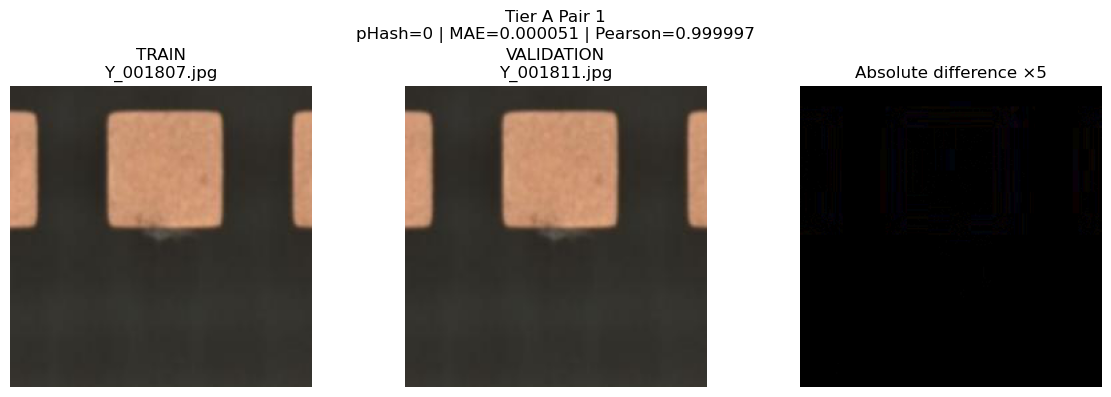

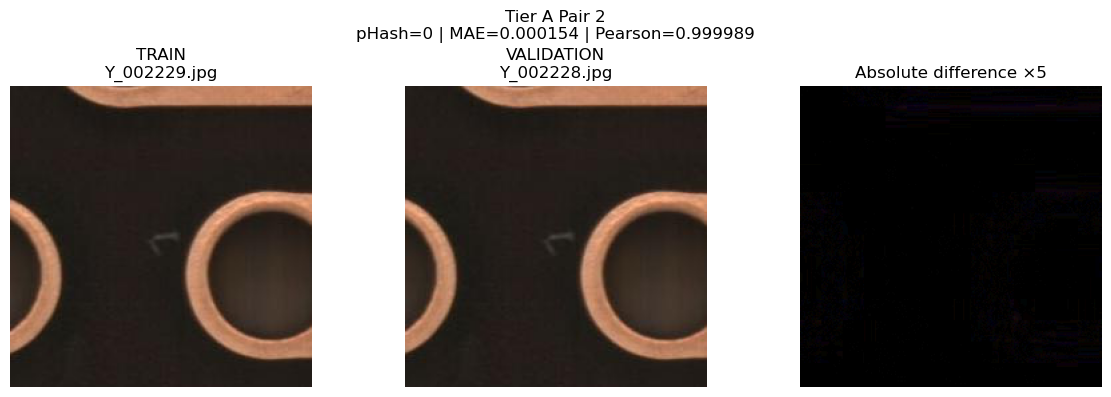

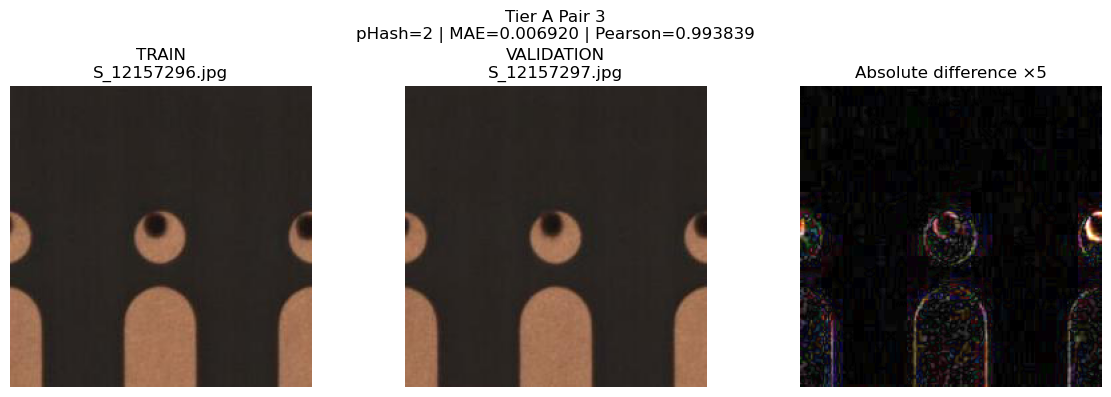

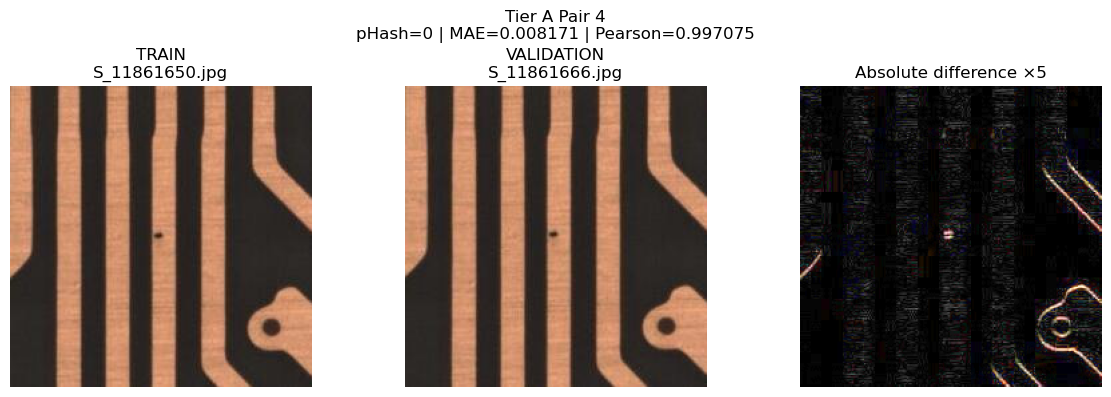

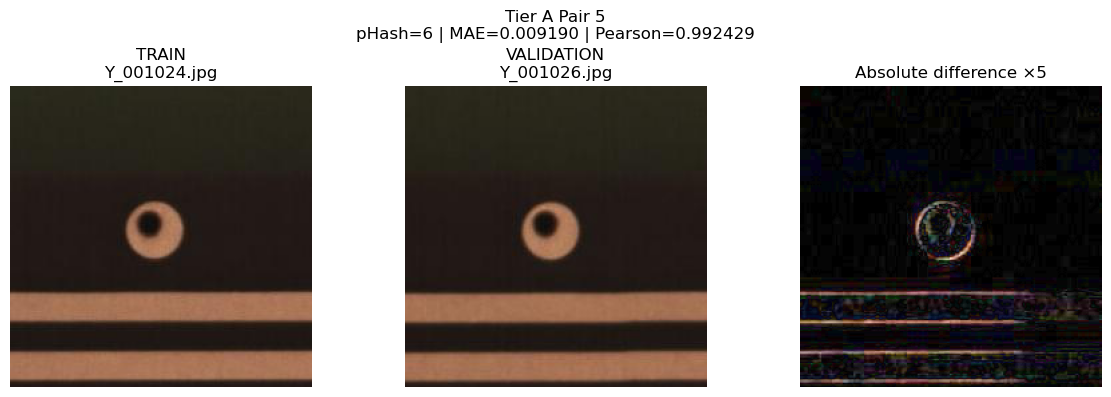

In [13]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

print("Displaying Tier A candidates for manual review...")


def load_rgb(path):
    img = cv2.imread(str(path))

    if img is None:
        raise RuntimeError(f"Cannot read {path}")

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


for i, row in enumerate(tier_a.itertuples(index=False), start=1):

    train_path = train_lookup[row.train_file]
    val_path = val_lookup[row.val_file]

    train_img = load_rgb(train_path)
    val_img = load_rgb(val_path)

    # Resize validation image only for visual pixel-difference comparison
    if train_img.shape != val_img.shape:
        val_for_diff = cv2.resize(
            val_img,
            (train_img.shape[1], train_img.shape[0]),
            interpolation=cv2.INTER_AREA
        )
    else:
        val_for_diff = val_img

    diff = cv2.absdiff(
        train_img,
        val_for_diff
    )

    # Amplify small differences for visibility
    diff_amplified = np.clip(
        diff.astype(np.float32) * 5,
        0,
        255
    ).astype(np.uint8)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12, 4)
    )

    axes[0].imshow(train_img)
    axes[0].set_title(
        f"TRAIN\n{row.train_file}"
    )

    axes[1].imshow(val_img)
    axes[1].set_title(
        f"VALIDATION\n{row.val_file}"
    )

    axes[2].imshow(diff_amplified)
    axes[2].set_title(
        "Absolute difference ×5"
    )

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"Tier A Pair {i}\n"
        f"pHash={row.phash_distance} | "
        f"MAE={row.mae:.6f} | "
        f"Pearson={row.pearson:.6f}"
    )

    plt.tight_layout()
    plt.show()

In [14]:
import cv2
import numpy as np
import pandas as pd

print("Starting translation-aware similarity analysis...")


def load_gray_original(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise RuntimeError(f"Could not read: {path}")

    return img.astype(np.float32) / 255.0


def compare_at_shift(a, b, dx, dy):
    """
    Compare overlapping pixels after shifting b relative to a.
    dx > 0 means b is shifted right.
    dy > 0 means b is shifted down.
    """

    h, w = a.shape

    # Horizontal overlap
    if dx >= 0:
        ax1, ax2 = dx, w
        bx1, bx2 = 0, w - dx
    else:
        ax1, ax2 = 0, w + dx
        bx1, bx2 = -dx, w

    # Vertical overlap
    if dy >= 0:
        ay1, ay2 = dy, h
        by1, by2 = 0, h - dy
    else:
        ay1, ay2 = 0, h + dy
        by1, by2 = -dy, h

    a_crop = a[ay1:ay2, ax1:ax2]
    b_crop = b[by1:by2, bx1:bx2]

    if a_crop.size == 0 or b_crop.size == 0:
        return None

    mae = float(np.mean(np.abs(a_crop - b_crop)))

    aa = a_crop.ravel()
    bb = b_crop.ravel()

    if np.std(aa) == 0 or np.std(bb) == 0:
        pearson = np.nan
    else:
        pearson = float(np.corrcoef(aa, bb)[0, 1])

    overlap_fraction = a_crop.size / a.size

    return mae, pearson, overlap_fraction


def best_translation_match(a, b, max_shift=10):

    # Only compare equal-sized arrays directly.
    # If dimensions differ, resize b only for this diagnostic test.
    if a.shape != b.shape:
        b = cv2.resize(
            b,
            (a.shape[1], a.shape[0]),
            interpolation=cv2.INTER_AREA
        )

    best = None

    for dy in range(-max_shift, max_shift + 1):
        for dx in range(-max_shift, max_shift + 1):

            result = compare_at_shift(a, b, dx, dy)

            if result is None:
                continue

            mae, pearson, overlap = result

            # Require substantial overlap
            if overlap < 0.85:
                continue

            if best is None or mae < best["aligned_mae"]:
                best = {
                    "dx": dx,
                    "dy": dy,
                    "aligned_mae": mae,
                    "aligned_pearson": pearson,
                    "overlap_fraction": overlap,
                }

    return best


alignment_records = []

total = len(tier_c)

for i, row in enumerate(tier_c.itertuples(index=False), start=1):

    train_path = train_lookup[row.train_file]
    val_path = val_lookup[row.val_file]

    train_img = load_gray_original(train_path)
    val_img = load_gray_original(val_path)

    best = best_translation_match(
        train_img,
        val_img,
        max_shift=10
    )

    alignment_records.append({
        "train_file": row.train_file,
        "val_file": row.val_file,
        "phash_distance": row.phash_distance,
        "original_mae": row.mae,
        "original_pearson": row.pearson,
        "best_dx": best["dx"],
        "best_dy": best["dy"],
        "aligned_mae": best["aligned_mae"],
        "aligned_pearson": best["aligned_pearson"],
        "overlap_fraction": best["overlap_fraction"],
    })

    if i % 20 == 0:
        print(f"Checked {i:,} / {total:,} pairs")


print(f"Checked {total:,} / {total:,} pairs")

alignment_df = pd.DataFrame(alignment_records)

alignment_df["shift_magnitude"] = np.sqrt(
    alignment_df["best_dx"] ** 2
    + alignment_df["best_dy"] ** 2
)

alignment_df["mae_improvement"] = (
    alignment_df["original_mae"]
    - alignment_df["aligned_mae"]
)


print("\n=== ALIGNMENT-AWARE SUMMARY ===")

print("Tier-C pairs checked:", len(alignment_df))

print("\nAligned MAE:")
print(
    alignment_df["aligned_mae"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nAligned Pearson:")
print(
    alignment_df["aligned_pearson"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)


print("\n=== HIGH-SIMILARITY AFTER ALIGNMENT ===")

for mae_t, corr_t in [
    (0.010, 0.990),
    (0.015, 0.985),
    (0.020, 0.980),
]:
    count = (
        (alignment_df["aligned_mae"] <= mae_t)
        & (alignment_df["aligned_pearson"] >= corr_t)
    ).sum()

    print(
        f"MAE <= {mae_t:.3f} AND Pearson >= {corr_t:.3f}: "
        f"{count}"
    )


final_shortlist = alignment_df[
    (alignment_df["aligned_mae"] <= 0.015)
    & (alignment_df["aligned_pearson"] >= 0.985)
].copy()

final_shortlist = final_shortlist.sort_values(
    ["aligned_mae", "aligned_pearson"],
    ascending=[True, False]
)


print("\n=== FINAL MANUAL-REVIEW SHORTLIST ===")
print("Pairs:", len(final_shortlist))

print(
    final_shortlist[
        [
            "train_file",
            "val_file",
            "best_dx",
            "best_dy",
            "aligned_mae",
            "aligned_pearson",
            "overlap_fraction",
        ]
    ].to_string(index=False)
)


OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tables"

alignment_df.to_csv(
    OUTPUT_DIR / "cross_split_alignment_analysis.csv",
    index=False
)

final_shortlist.to_csv(
    OUTPUT_DIR / "cross_split_final_manual_review.csv",
    index=False
)

print("\nSaved alignment results.")

Starting translation-aware similarity analysis...
Checked 20 / 113 pairs
Checked 40 / 113 pairs
Checked 60 / 113 pairs
Checked 80 / 113 pairs
Checked 100 / 113 pairs
Checked 113 / 113 pairs

=== ALIGNMENT-AWARE SUMMARY ===
Tier-C pairs checked: 113

Aligned MAE:
count    113.000000
mean       0.018576
std        0.007186
min        0.000058
25%        0.015400
50%        0.019927
75%        0.023874
90%        0.026298
95%        0.028047
99%        0.030163
max        0.031679
Name: aligned_mae, dtype: float64

Aligned Pearson:
count    113.000000
mean       0.988802
std        0.006693
min        0.968755
25%        0.985403
50%        0.989373
75%        0.992600
90%        0.998612
95%        0.999354
99%        0.999959
max        0.999996
Name: aligned_pearson, dtype: float64

=== HIGH-SIMILARITY AFTER ALIGNMENT ===
MAE <= 0.010 AND Pearson >= 0.990: 17
MAE <= 0.015 AND Pearson >= 0.985: 24
MAE <= 0.020 AND Pearson >= 0.980: 53

=== FINAL MANUAL-REVIEW SHORTLIST ===
Pairs: 24
   

Creating final manual-review pages...


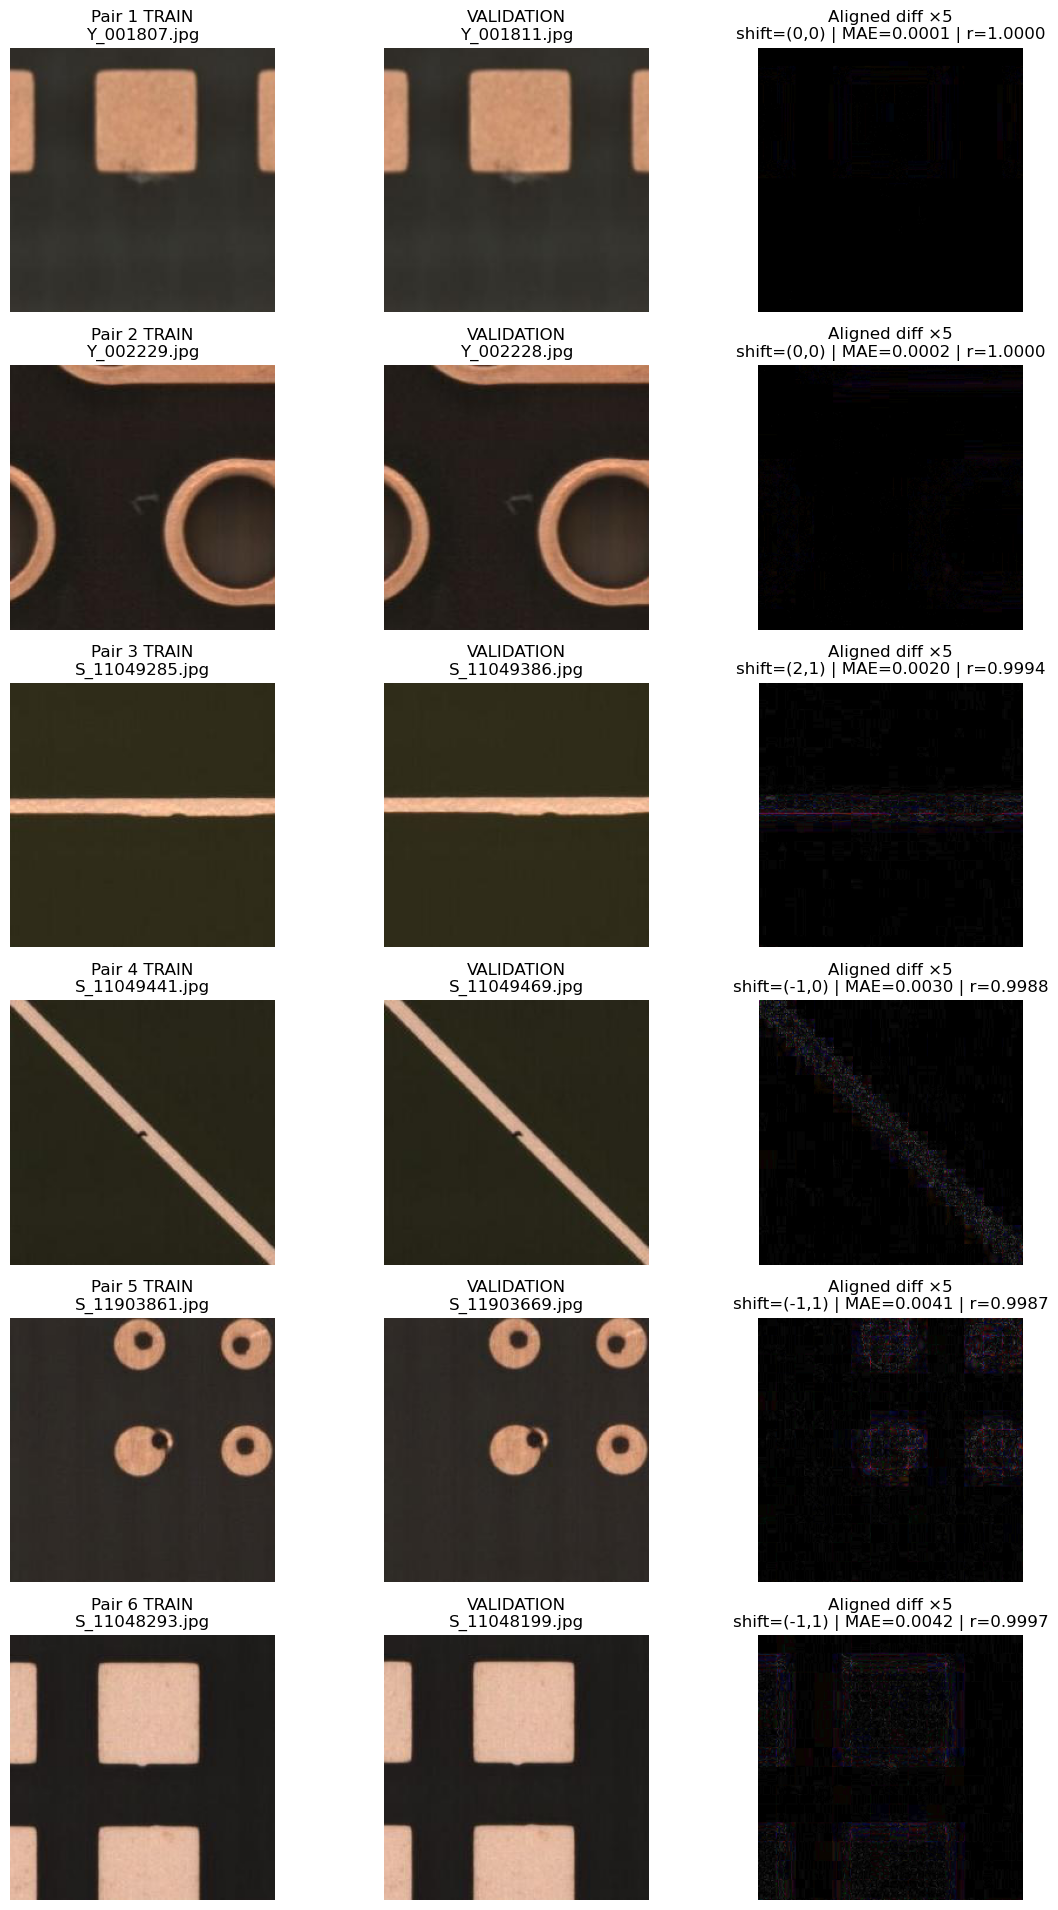

Displayed review page 1/4: pairs 1-6


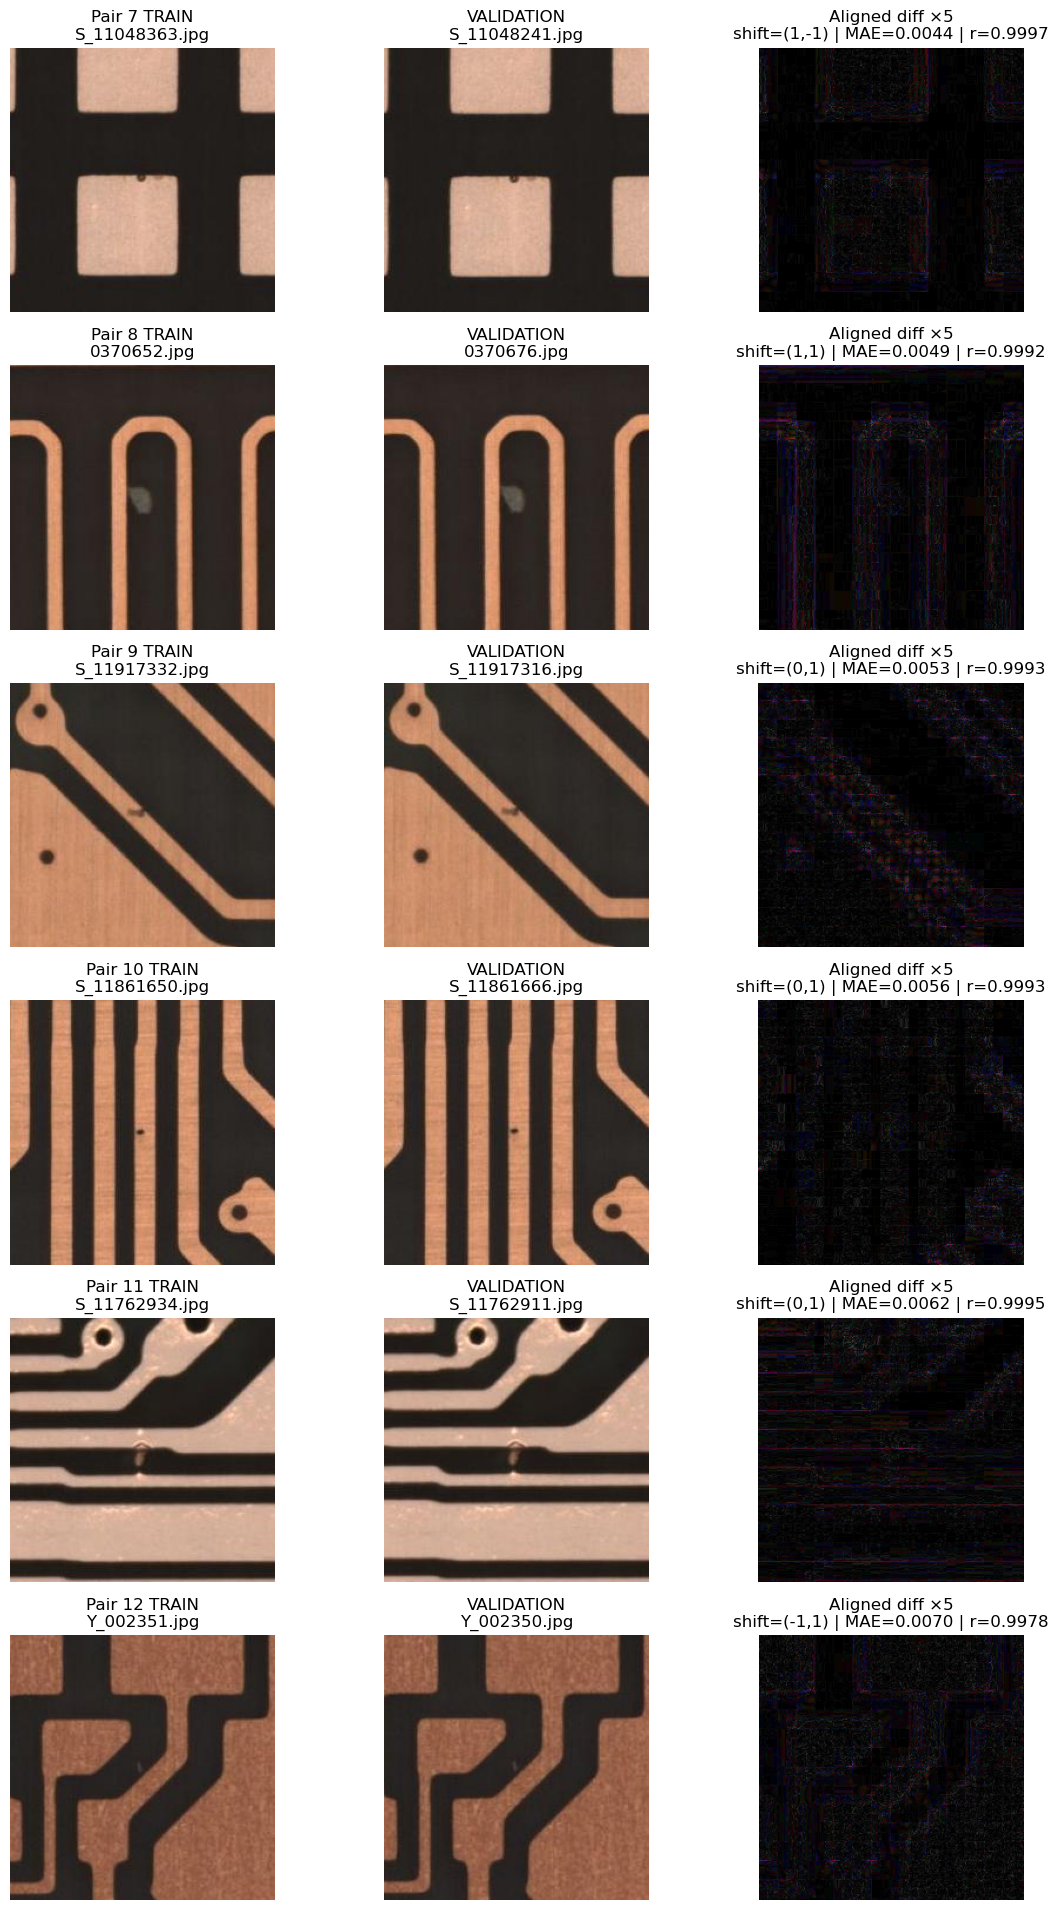

Displayed review page 2/4: pairs 7-12


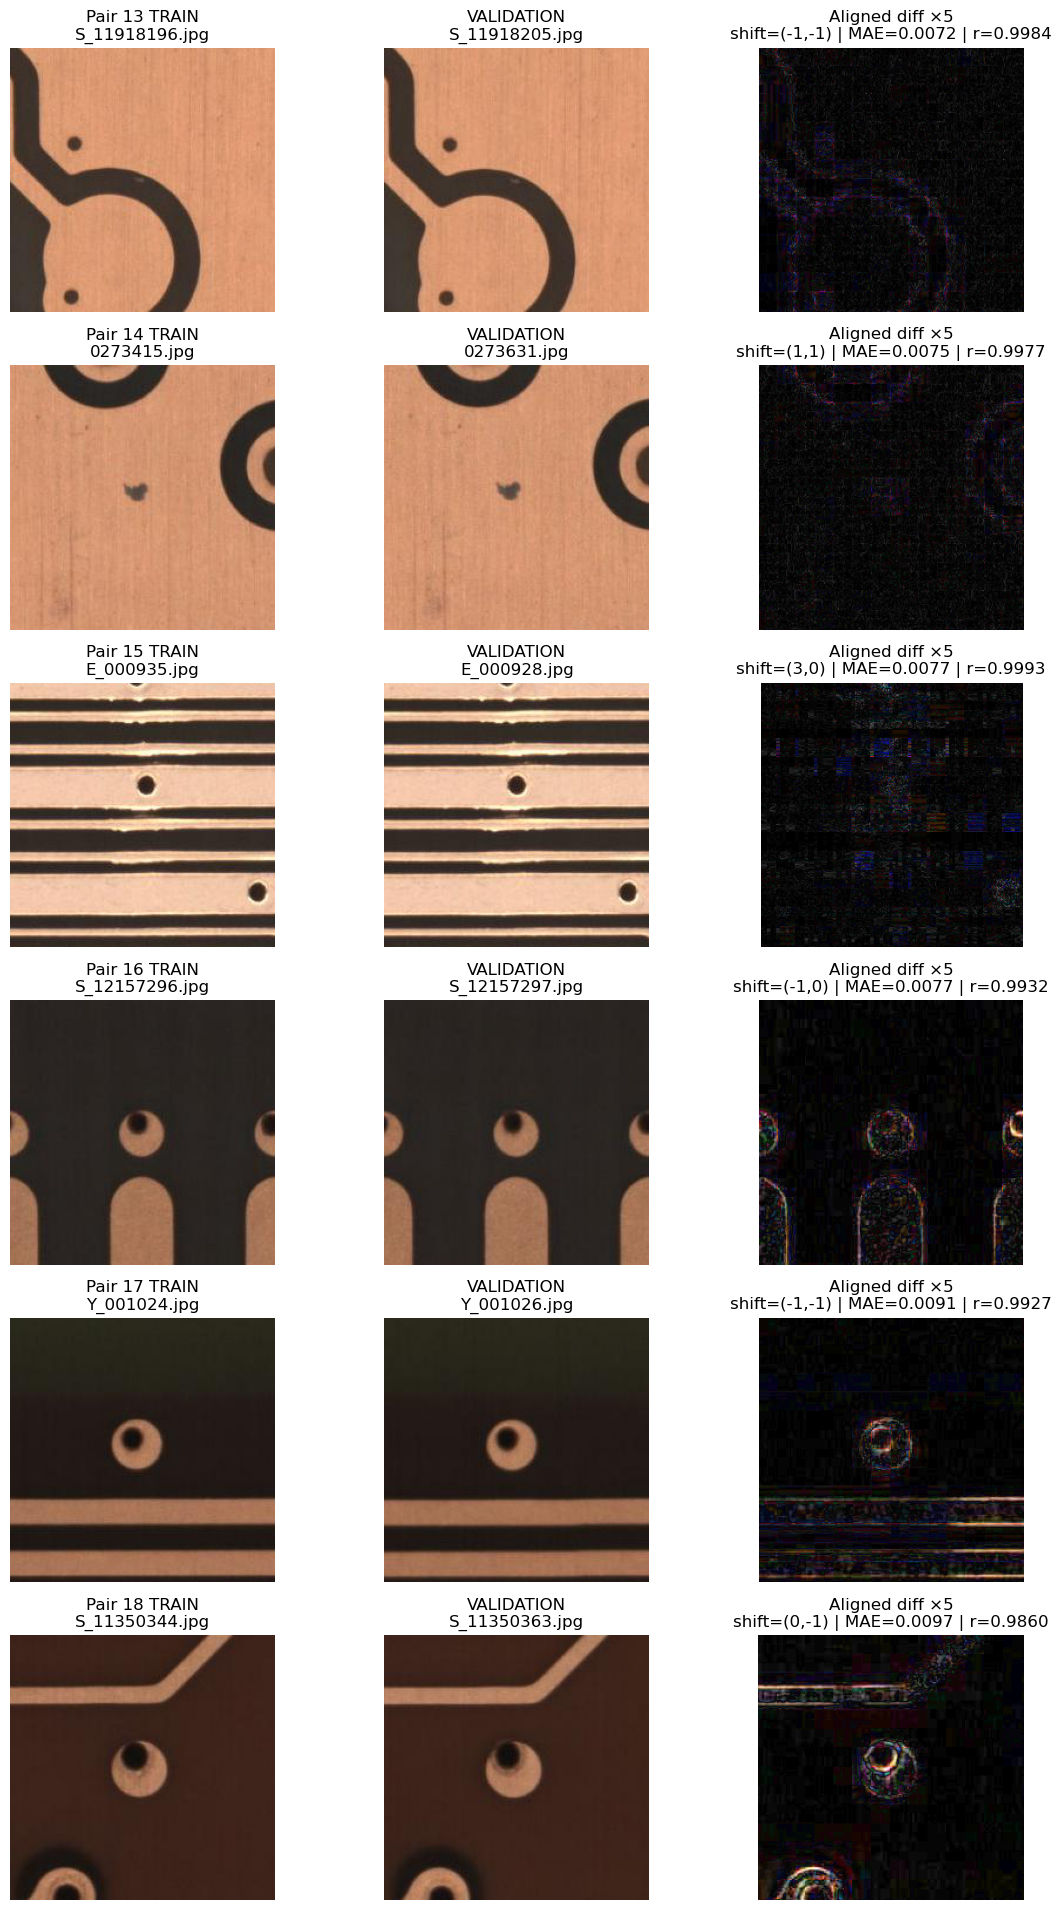

Displayed review page 3/4: pairs 13-18


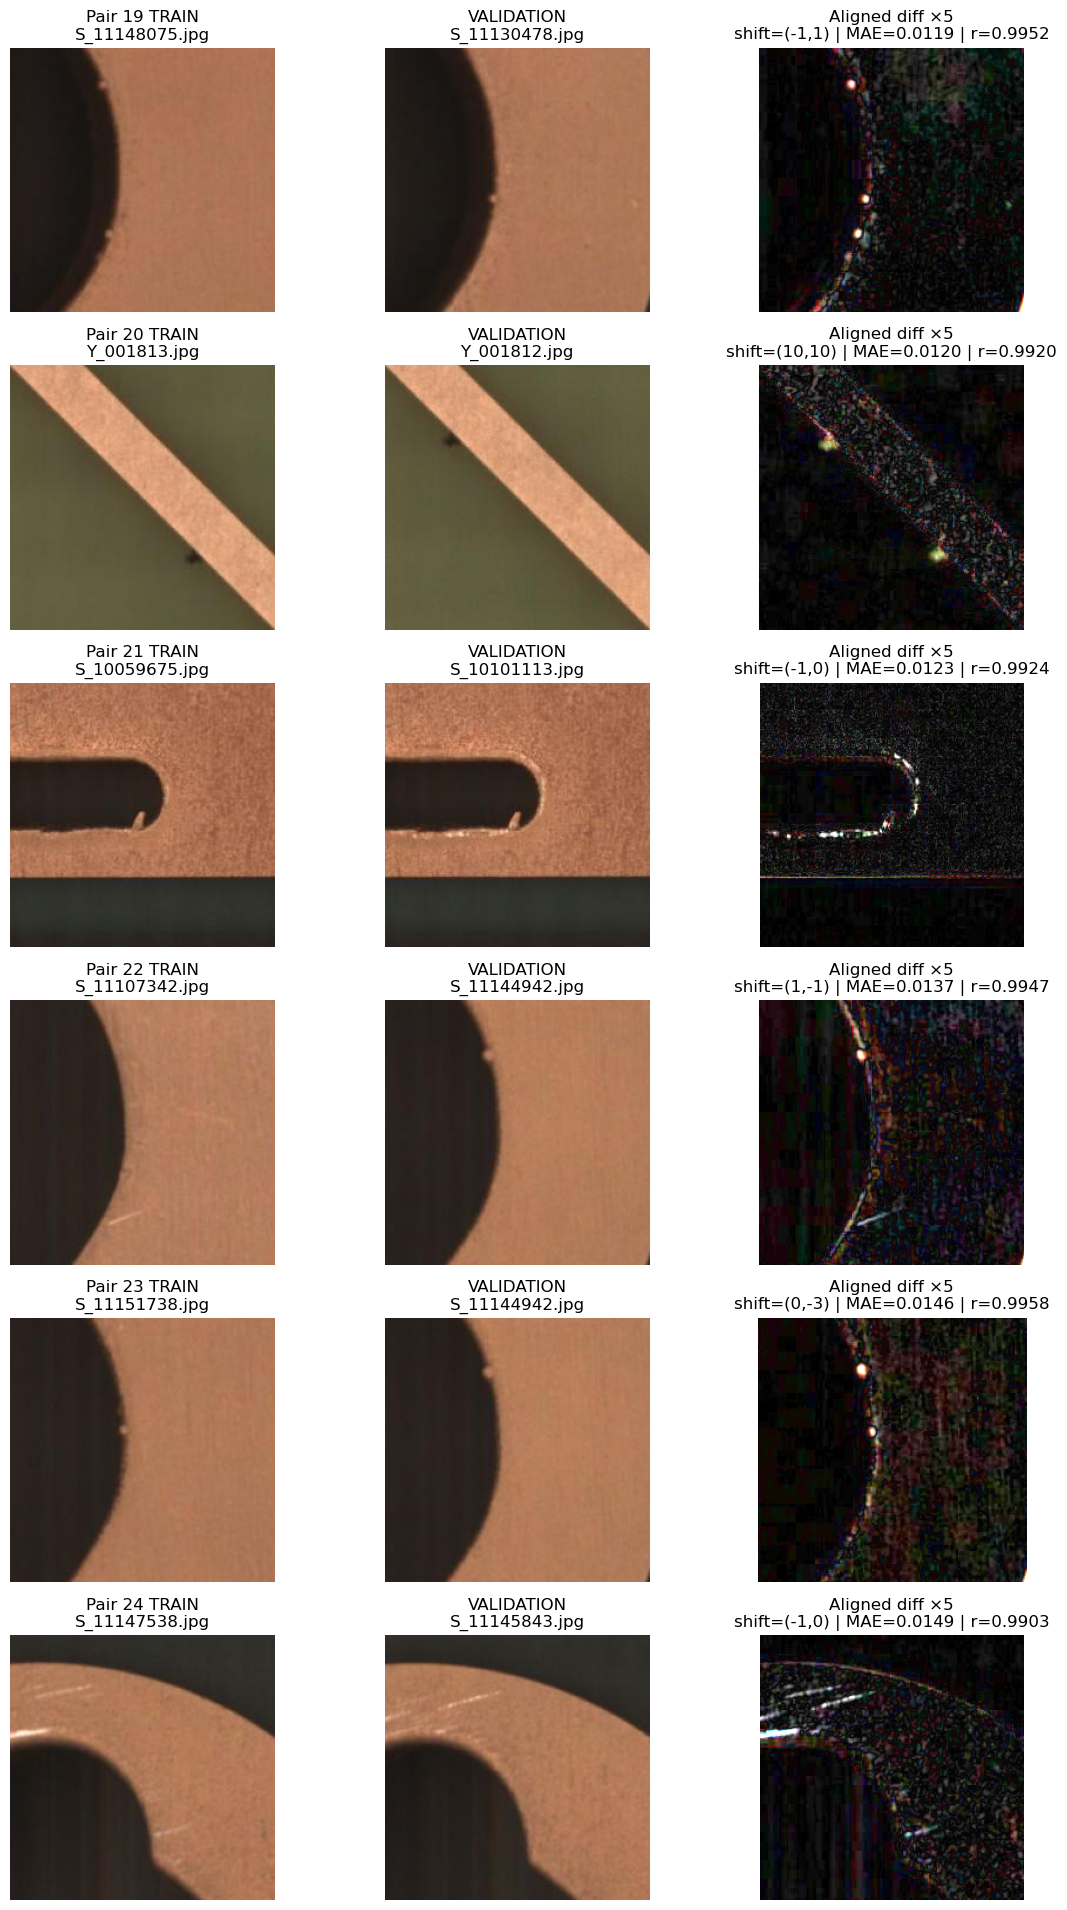

Displayed review page 4/4: pairs 19-24


In [15]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import math

print("Creating final manual-review pages...")


def read_rgb(path):
    img = cv2.imread(str(path))

    if img is None:
        raise RuntimeError(f"Cannot read {path}")

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def align_for_display(train_img, val_img, dx, dy):
    """
    Produce overlapping train/validation crops using the
    shift found during the alignment audit.
    """

    if train_img.shape != val_img.shape:
        val_img = cv2.resize(
            val_img,
            (train_img.shape[1], train_img.shape[0]),
            interpolation=cv2.INTER_AREA
        )

    h, w = train_img.shape[:2]

    if dx >= 0:
        ax1, ax2 = dx, w
        bx1, bx2 = 0, w - dx
    else:
        ax1, ax2 = 0, w + dx
        bx1, bx2 = -dx, w

    if dy >= 0:
        ay1, ay2 = dy, h
        by1, by2 = 0, h - dy
    else:
        ay1, ay2 = 0, h + dy
        by1, by2 = -dy, h

    a = train_img[ay1:ay2, ax1:ax2]
    b = val_img[by1:by2, bx1:bx2]

    return a, b


review_df = final_shortlist.reset_index(drop=True)

PAIRS_PER_PAGE = 6
pages = math.ceil(len(review_df) / PAIRS_PER_PAGE)

for page in range(pages):

    start = page * PAIRS_PER_PAGE
    end = min(start + PAIRS_PER_PAGE, len(review_df))

    subset = review_df.iloc[start:end]

    fig, axes = plt.subplots(
        len(subset),
        3,
        figsize=(12, 3.2 * len(subset))
    )

    if len(subset) == 1:
        axes = np.array([axes])

    for row_idx, (_, row) in enumerate(subset.iterrows()):

        train_img = read_rgb(train_lookup[row["train_file"]])
        val_img = read_rgb(val_lookup[row["val_file"]])

        aligned_train, aligned_val = align_for_display(
            train_img,
            val_img,
            int(row["best_dx"]),
            int(row["best_dy"])
        )

        diff = cv2.absdiff(
            aligned_train,
            aligned_val
        )

        diff = np.clip(
            diff.astype(np.float32) * 5,
            0,
            255
        ).astype(np.uint8)

        pair_number = start + row_idx + 1

        axes[row_idx, 0].imshow(train_img)
        axes[row_idx, 0].set_title(
            f"Pair {pair_number} TRAIN\n{row['train_file']}"
        )

        axes[row_idx, 1].imshow(val_img)
        axes[row_idx, 1].set_title(
            f"VALIDATION\n{row['val_file']}"
        )

        axes[row_idx, 2].imshow(diff)
        axes[row_idx, 2].set_title(
            f"Aligned diff ×5\n"
            f"shift=({int(row['best_dx'])},{int(row['best_dy'])}) | "
            f"MAE={row['aligned_mae']:.4f} | "
            f"r={row['aligned_pearson']:.4f}"
        )

        for ax in axes[row_idx]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(
        f"Displayed review page {page + 1}/{pages}: "
        f"pairs {start + 1}-{end}"
    )

In [16]:
# ============================================================
# Record final manual review decisions
# ============================================================

manual_labels = {
    1: "A",
    2: "A",
    3: "A",
    4: "A",
    5: "A",
    6: "A",
    7: "A",
    8: "A",
    9: "A",
    10: "A",
    11: "A",
    12: "A",
    13: "A",
    14: "A",
    15: "A",
    16: "A",
    17: "A",
    18: "A",
    19: "B",
    20: "B",
    21: "A",
    22: "B",
    23: "B",
    24: "B",
}

manual_review_df = final_shortlist.reset_index(drop=True).copy()

manual_review_df.insert(
    0,
    "pair_id",
    range(1, len(manual_review_df) + 1)
)

manual_review_df["manual_label"] = (
    manual_review_df["pair_id"].map(manual_labels)
)

print("=== MANUAL REVIEW COUNTS ===")
print(
    manual_review_df["manual_label"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# High-confidence near-duplicates only
# ------------------------------------------------------------

confirmed = manual_review_df[
    manual_review_df["manual_label"] == "A"
].copy()

unique_train = confirmed["train_file"].nunique()
unique_val = confirmed["val_file"].nunique()

print("\n=== HIGH-CONFIDENCE CROSS-SPLIT NEAR-DUPLICATES ===")
print("Confirmed pairs:", len(confirmed))

print(
    "Unique affected training images:",
    unique_train,
    f"({unique_train / len(train_images) * 100:.3f}%)"
)

print(
    "Unique affected validation images:",
    unique_val,
    f"({unique_val / len(val_images) * 100:.3f}%)"
)

print(
    "Total unique affected images:",
    len(
        set(confirmed["train_file"])
        | set(confirmed["val_file"])
    )
)

# ------------------------------------------------------------
# Save reproducible records
# ------------------------------------------------------------

manual_review_df.to_csv(
    OUTPUT_DIR / "cross_split_manual_review.csv",
    index=False
)

confirmed.to_csv(
    OUTPUT_DIR / "cross_split_high_confidence_near_duplicates.csv",
    index=False
)

print("\nSaved:")
print(
    OUTPUT_DIR / "cross_split_manual_review.csv"
)
print(
    OUTPUT_DIR / "cross_split_high_confidence_near_duplicates.csv"
)

=== MANUAL REVIEW COUNTS ===
manual_label
A    19
B     5
Name: count, dtype: int64

=== HIGH-CONFIDENCE CROSS-SPLIT NEAR-DUPLICATES ===
Confirmed pairs: 19
Unique affected training images: 19 (0.231%)
Unique affected validation images: 19 (0.926%)
Total unique affected images: 38

Saved:
/scr/user/danielw9199/TrustPCB/outputs/tables/cross_split_manual_review.csv
/scr/user/danielw9199/TrustPCB/outputs/tables/cross_split_high_confidence_near_duplicates.csv


In [17]:
import pandas as pd
from pathlib import Path

print("Creating final DsPCBSD+ audit summary...")

audit_summary = [
    ("Official dataset", "DsPCBSD+"),
    ("Total images", 10259),
    ("Training images", 8208),
    ("Validation images", 2051),
    ("Unreadable images", 0),

    ("226x226 images", 10148),
    ("108x108 images", 111),

    ("Total label files", 10259),
    ("Images without labels", 0),
    ("Labels without images", 0),

    ("Total annotations", 20276),
    ("Structurally valid annotations", 20276),
    ("Other annotation issues", 0),

    ("Nominal boundary-overflow boxes", 277),
    ("Maximum boundary overflow px", 0.0113),

    ("Number of classes", 9),
    ("Smallest class boxes", 915),
    ("Largest class boxes", 4584),
    ("Largest/smallest class ratio", 5.01),

    ("Boxes below 1% crop area", 11082),
    ("Boxes below 1% crop area percentage", 54.66),

    ("Boxes below 0.25% crop area", 3265),
    ("Boxes below 0.25% crop area percentage", 16.10),

    ("Exact pixel duplicate groups", 0),
    ("Cross-split exact duplicate groups", 0),

    ("pHash screening candidates <=10", 3993),
    ("Tier-C high-similarity candidates", 113),
    ("Final manual-review candidates", 24),

    ("High-confidence near-duplicate pairs", 19),
    ("Related but non-confirmed pairs", 5),

    ("Affected training images", 19),
    ("Affected training percentage", 0.231),

    ("Affected validation images", 19),
    ("Affected validation percentage", 0.926),

    ("Total affected unique images", 38),
]

audit_summary_df = pd.DataFrame(
    audit_summary,
    columns=["metric", "value"]
)

OUTPUT_DIR = (
    Path("/scr/user/danielw9199/TrustPCB")
    / "outputs"
    / "tables"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUTPUT_DIR / "dataset_audit_summary.csv"

audit_summary_df.to_csv(
    summary_path,
    index=False
)

print("\n=== FINAL DATASET AUDIT SUMMARY ===")
print(audit_summary_df.to_string(index=False))

print("\nSaved:")
print(summary_path)

print("\n=== AUDIT CONCLUSION ===")
print(
    "DsPCBSD+ passed the basic integrity audit. "
    "No unreadable images, missing image-label pairs, "
    "structural annotation errors, or exact pixel duplicates "
    "were detected. A small set of highly similar cross-split "
    "image pairs was identified and will be addressed through "
    "similarity-aware evaluation."
)

Creating final DsPCBSD+ audit summary...

=== FINAL DATASET AUDIT SUMMARY ===
                                metric    value
                      Official dataset DsPCBSD+
                          Total images    10259
                       Training images     8208
                     Validation images     2051
                     Unreadable images        0
                        226x226 images    10148
                        108x108 images      111
                     Total label files    10259
                 Images without labels        0
                 Labels without images        0
                     Total annotations    20276
        Structurally valid annotations    20276
               Other annotation issues        0
       Nominal boundary-overflow boxes      277
          Maximum boundary overflow px   0.0113
                     Number of classes        9
                  Smallest class boxes      915
                   Largest class boxes     4584
          